# Inspect Cluster Lifecycle Report

This notebook loads a `graphcluster` lifecycle report artifact written during a streaming run and gives a quick way to inspect the most useful data without rerunning the trajectory pipeline.

The current report artifact contains:
- trajectory-level summary counts
- per-frame cluster counts and changed-atom counts
- birth, death, split, and merge events
- per-atom switch counts
- simple cluster lifetime records
- optional per-cluster raw Allegro energy summaries when available


In [1]:
import sys
print(sys.executable)

/n/holylabs/kozinsky_lab/Users/lsteinberger/conda/envs/nequip311/bin/python


In [2]:
from pathlib import Path
from pprint import pprint

from graphcluster.analysis.lifecycle_report import ClusterLifecycleReport

# Change this path if you want to inspect a different run.
REPORT_PATH = Path("/n/home12/lsteinberger/systems/hpt/analysis/cluster/outputs/hpt_600k_allegro/cluster_lifecycle_report.json")

if not REPORT_PATH.exists():
    raise FileNotFoundError(f"Could not find report artifact: {REPORT_PATH}")

report = ClusterLifecycleReport.from_path(REPORT_PATH)
REPORT_PATH


PosixPath('/n/home12/lsteinberger/systems/hpt/analysis/cluster/outputs/hpt_600k_allegro/cluster_lifecycle_report.json')

In [3]:
print("Source:", report.source_path)
print("Summary:")
pprint(report.get_summary_table())

print("\nEvent counts:")
pprint(report.get_event_counts())


Source: /n/home12/lsteinberger/systems/hpt/analysis/cluster/outputs/hpt_600k_allegro/cluster_lifecycle_report.json
Summary:
{'num_atoms': 1312,
 'num_frames': 20,
 'num_tracked_clusters': 217,
 'total_births': 217,
 'total_deaths': 182,
 'total_merges': 305,
 'total_splits': 293}

Event counts:
{'total_births': 217,
 'total_deaths': 182,
 'total_merges': 305,
 'total_splits': 293}


In [4]:
births = report.get_births()
deaths = report.get_deaths()
splits = report.get_splits()
merges = report.get_merges()

print("Birth frames:", len(births))
print("Death frames:", len(deaths))
print("Split frames:", len(splits))
print("Merge frames:", len(merges))

print("\nFirst few birth events:")
pprint(births[:3])

print("\nFirst few death events:")
pprint(deaths[:3])

print("\nFirst split frame:")
pprint(splits[:1])

print("\nFirst merge frame:")
pprint(merges[:1])


Birth frames: 20
Death frames: 19
Split frames: 19
Merge frames: 19

First few birth events:
[{'cluster_ids': [0,
                  1,
                  2,
                  3,
                  4,
                  5,
                  6,
                  7,
                  8,
                  9,
                  10,
                  11,
                  12,
                  13,
                  14,
                  15,
                  16,
                  17,
                  18,
                  19,
                  20,
                  21,
                  22,
                  23,
                  24,
                  25,
                  26,
                  27,
                  28,
                  29,
                  30,
                  31,
                  32,
                  33,
                  34],
  'frame_index': 0},
 {'cluster_ids': [35,
                  36,
                  37,
                  38,
                  39,
               

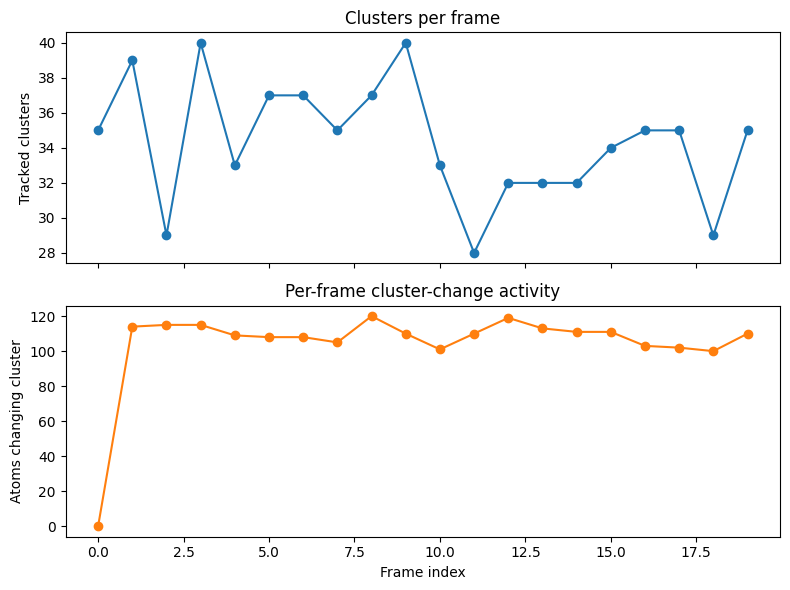

In [5]:
fig, axes = report.plot_cluster_count_timeseries()


Number of atoms: 1312
Max switch count: 19
Atoms with at least one switch: 162

Top active atoms:
[{'atom_index': 1306, 'switch_count': 19},
 {'atom_index': 1307, 'switch_count': 19},
 {'atom_index': 1206, 'switch_count': 18},
 {'atom_index': 1207, 'switch_count': 18},
 {'atom_index': 1262, 'switch_count': 17},
 {'atom_index': 1263, 'switch_count': 17},
 {'atom_index': 1266, 'switch_count': 17},
 {'atom_index': 1267, 'switch_count': 17},
 {'atom_index': 1164, 'switch_count': 16},
 {'atom_index': 1165, 'switch_count': 16}]


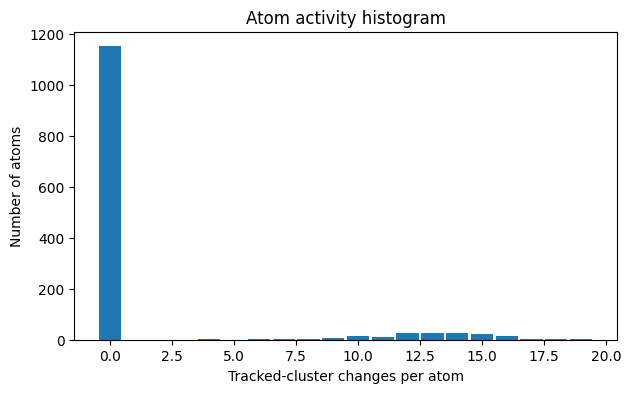

In [6]:
atom_switch_counts = report.get_atom_switch_counts()

print("Number of atoms:", len(atom_switch_counts))
print("Max switch count:", max(atom_switch_counts) if atom_switch_counts else 0)
print("Atoms with at least one switch:", report.get_num_active_atoms(min_switches=1))

print("\nTop active atoms:")
pprint(report.get_top_atoms_by_switches(10))

fig, ax = report.plot_atom_switch_histogram()


Top cluster lifetimes:
[{'cluster_id': 0,
  'first_seen_frame': 0,
  'frames_observed': 20,
  'last_seen_frame': 19},
 {'cluster_id': 26,
  'first_seen_frame': 0,
  'frames_observed': 20,
  'last_seen_frame': 19},
 {'cluster_id': 73,
  'first_seen_frame': 4,
  'frames_observed': 16,
  'last_seen_frame': 19},
 {'cluster_id': 25,
  'first_seen_frame': 0,
  'frames_observed': 14,
  'last_seen_frame': 13},
 {'cluster_id': 61,
  'first_seen_frame': 3,
  'frames_observed': 14,
  'last_seen_frame': 16},
 {'cluster_id': 105,
  'first_seen_frame': 7,
  'frames_observed': 11,
  'last_seen_frame': 17},
 {'cluster_id': 113,
  'first_seen_frame': 8,
  'frames_observed': 11,
  'last_seen_frame': 18},
 {'cluster_id': 127,
  'first_seen_frame': 9,
  'frames_observed': 11,
  'last_seen_frame': 19},
 {'cluster_id': 128,
  'first_seen_frame': 9,
  'frames_observed': 11,
  'last_seen_frame': 19},
 {'cluster_id': 15,
  'first_seen_frame': 0,
  'frames_observed': 9,
  'last_seen_frame': 8}]


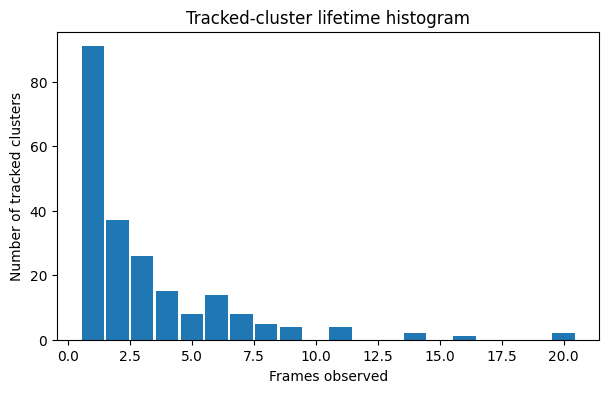

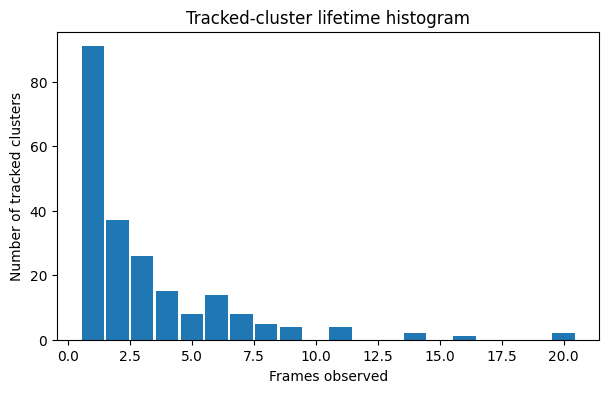

In [7]:
print("Top cluster lifetimes:")
pprint(report.get_longest_lived_clusters(10))

fig, ax = report.plot_cluster_lifetime_histogram()
fig


## Cluster Energy

If the lifecycle report was written with `cluster_energy.enabled: true` and the source frames carried raw Allegro edge metadata, the report facade can return and plot per-cluster raw directed energy sums over time.


Cluster energy available: True
Showing Allegro cluster energies for tracked cluster 26
2
2
16
2
11
2
2
10
2
4
2
10
2
4
4
2
10
8
2
4
[{'cluster_id': 26,
  'combined_energy': -259.04837955728635,
  'combined_energy_per_atom': -129.52418977864318,
  'combined_model_energy': -391.98845158964497,
  'combined_model_energy_per_atom': -195.99422579482248,
  'external_energy': 6.062830834707711e-06,
  'external_energy_per_atom': 3.0314154173538554e-06,
  'external_model_energy': 9.121879224659393e-06,
  'external_model_energy_per_atom': 4.5609396123296965e-06,
  'frame_index': 0,
  'internal_energy': -259.0483856201172,
  'internal_energy_per_atom': -129.5241928100586,
  'internal_model_energy': -389.75326071152415,
  'internal_model_energy_per_atom': -194.87663035576207,
  'shift_energy': -2.2352,
  'shift_energy_per_atom': -1.1176,
  'size': 2},
 {'cluster_id': 26,
  'combined_energy': -259.0531784396844,
  'combined_energy_per_atom': -129.5265892198422,
  'combined_model_energy': -391.995671

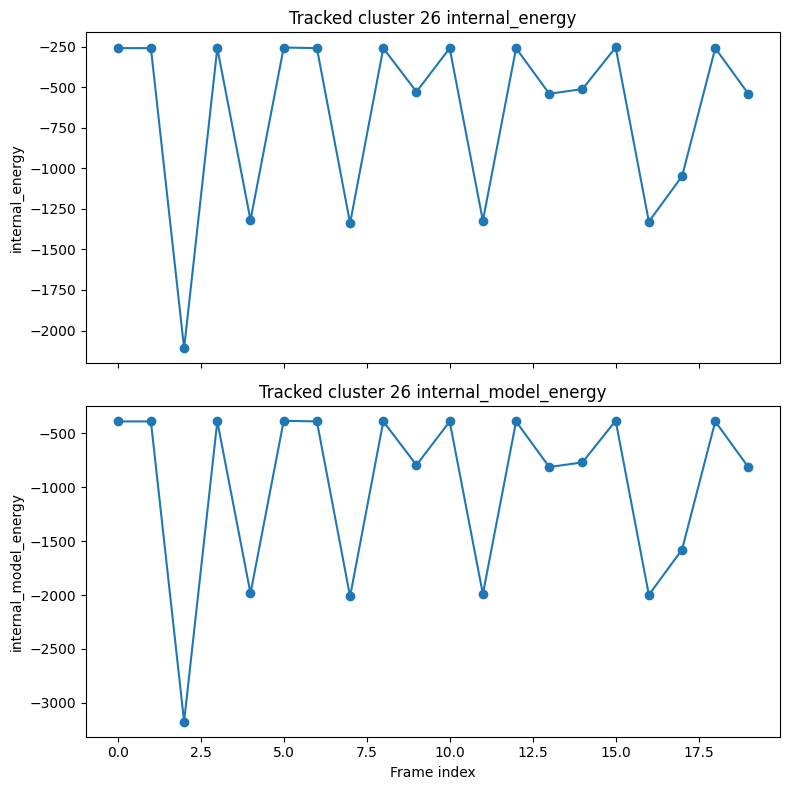

In [14]:
print("Cluster energy available:", report.has_cluster_energy())

if report.has_cluster_energy():
    CLUSTER_ID = 26  # easy switch
    energy_timeseries = report.get_cluster_energy_timeseries(CLUSTER_ID)
    print(f"Showing Allegro cluster energies for tracked cluster {CLUSTER_ID}")
    for frame in energy_timeseries:
        print(frame["size"])
    pprint(energy_timeseries[:6])

    fig, axes = report.plot_cluster_energy_timeseries(
        CLUSTER_ID,
        components=(
            "internal_energy",
            #"external_energy_per_atom",
            "internal_model_energy",
            #"external_model_energy",
            #"shift_energy",
        ),
    )

else:
    print("This report does not contain cluster energy summaries.")


## Next ideas

Natural extensions for this notebook later:
- filter events for a specific frame or tracked cluster
- compare report events against the visualization artifact for the same frame
- plot match-confidence distributions once those are exposed on the report facade
- export selected tables to CSV for external analysis
